In [21]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import os
import pathlib

# Lightning check of DOF e5 household trends relative to population trends
See [Asana: Household growth tracking as an indicator](https://app.asana.com/1/11860278793487/project/1203667963226617/task/1214019059343830?focus=true) task.

In [22]:
bayareafips_full = {'06001': 'Alameda', '06013': 'Contra Costa', '06041': 'Marin', '06055': 'Napa',
                    '06075': 'San Francisco', '06081': 'San Mateo', '06085': 'Santa Clara',
                    '06097': 'Sonoma', '06095': 'Solano'}

bayareareg = dict([(k, 'ABAG/MTC') for k in bayareafips_full])

## DOF E5

In [23]:
M_DRIVE = pathlib.Path('/Volumes/Data/Models') if os.name != 'nt' else pathlib.Path('M:/')

e5wb_path = M_DRIVE / 'Data/California DoF/E5/E-5_2025_InternetVersion.xlsx'
e5wb = pd.ExcelFile(e5wb_path)

print(e5wb.sheet_names)

keep = {}
for i in range(2020,2026):

    data = e5wb.parse(f'E5CountyState{i}',skiprows=[0],header=[1,2])
    data.columns = pd.MultiIndex.from_tuples([(f[0].strip(),f[1]) for f in data.columns])

    keep[i]=data

e5 = pd.concat(keep,names=['year','oid']).reset_index().drop(['oid'],axis=1)

e5 = e5.rename(columns={'Unnamed: 0_level_0':'County'})

e5_long = e5.set_index(['year',('County','County')]).stack([0,1])

e5_long_bayarea = e5_long.loc[:, list(bayareafips_full.values())]
e5_long_bayarea.index = e5_long_bayarea.index.set_names(
    ['year', 'county', 'vargroup', 'variable'])

['E5CountyState2020', 'E5CityCounty2020', 'E5CountyState2021', 'E5CityCounty2021', 'E5CountyState2022', 'E5CityCounty2022', 'E5CountyState2023', 'E5CityCounty2023', 'E5CountyState2024', 'E5CityCounty2024', 'E5CountyState2025', 'E5CityCounty2025']


/var/folders/03/fgvd1kc91871lp3_mr1g8hlw0000gq/T/ipykernel_39567/2058006355.py:16: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  e5 = pd.concat(keep,names=['year','oid']).reset_index().drop(['oid'],axis=1)
/var/folders/03/fgvd1kc91871lp3_mr1g8hlw0000gq/T/ipykernel_39567/2058006355.py:20: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  e5_long = e5.set_index(['year',('County','County')]).stack([0,1])


# Exploratory Analysis

Just check the totals to make sure we subsetted the region properly

In [53]:
(e5_long_bayarea.loc[:, :, 'HOUSING UNITS', ['Occupied', 'Vacancy Rate','Total']]).unstack('variable').groupby(level=['year','county']).sum()

variable            Occupied  Vacancy Rate     Total
year county                                         
2020 Alameda        591636.0      0.048752  621958.0
     Contra Costa   407029.0      0.038534  423342.0
     Marin          104167.0      0.066303  111564.0
     Napa            49738.0      0.102979   55448.0
     San Francisco  371851.0      0.085525  406628.0
     San Mateo      269417.0      0.050322  283693.0
     Santa Clara    656063.0      0.046469  688035.0
     Solano         155924.0      0.038912  162237.0
     Sonoma         187701.0      0.083232  204742.0
2021 Alameda        595404.0      0.048819  625963.0
     Contra Costa   408665.0      0.038915  425212.0
     Marin          104277.0      0.066187  111668.0
     Napa            49569.0      0.100952   55135.0
     San Francisco  375684.0      0.085524  410819.0
     San Mateo      270675.0      0.050316  285016.0
     Santa Clara    660252.0      0.046448  692413.0
     Solano         156457.0      0.038915  162792.0
     Sonoma         188226.0      0.082880  205236.0
2022 Alameda        601528.0      0.050082  633242.0
     Contra Costa   411333.0      0.038436  427775.0
     Marin          104346.0      0.067332  111879.0
     Napa            50098.0      0.100332   55685.0
     San Francisco  377584.0      0.090851  415316.0
     San Mateo      272302.0      0.050316  286729.0
     Santa Clara    663380.0      0.047573  696515.0
     Solano         157348.0      0.039507  163820.0
     Sonoma         189643.0      0.082241  206637.0
2023 Alameda        610393.0      0.048949  641809.0
     Contra Costa   414084.0      0.038606  430712.0
     Marin          104685.0      0.066837  112183.0
     Napa            50284.0      0.100626   55910.0
     San Francisco  382285.0      0.085747  418139.0
     San Mateo      273492.0      0.050306  287979.0
     Santa Clara    668848.0      0.046599  701539.0
     Solano         158470.0      0.039826  165043.0
     Sonoma         190988.0      0.082820  208234.0
2024 Alameda        616095.0      0.049061  647881.0
     Contra Costa   416812.0      0.038660  433574.0
     Marin          104979.0      0.068245  112668.0
     Napa            50537.0      0.100461   56181.0
     San Francisco  384367.0      0.085746  420416.0
     San Mateo      275198.0      0.050327  289782.0
     Santa Clara    672807.0      0.046542  705649.0
     Solano         159956.0      0.040203  166656.0
     Sonoma         192967.0      0.081459  210080.0
2025 Alameda        620632.0      0.049099  652678.0
     Contra Costa   418955.0      0.038631  435790.0
     Marin          105347.0      0.068237  113062.0
     Napa            51160.0      0.099914   56839.0
     San Francisco  385822.0      0.085745  422007.0
     San Mateo      277385.0      0.050305  292078.0
     Santa Clara    676868.0      0.046549  709914.0
     Solano         161128.0      0.039847  167815.0
     Sonoma         195185.0      0.081296  212457.0

In [54]:
e5_long_bayarea.loc[:, :, 'POPULATION'].groupby(['year', 'variable']).sum().unstack(1).Total

year
2020    7765640.0
2021    7694791.0
2022    7603795.0
2023    7638118.0
2024    7653022.0
2025    7656691.0
Name: Total, dtype: float64

In [55]:
(e5_long_bayarea.loc[:, :, 'HOUSING UNITS', ['Occupied', 'Total']]).unstack('variable').diff(axis=1).groupby(level='year').sum()

variable,Occupied,Total
year,,
2020,0.0,164121.0
2021,0.0,165045.0
2022,0.0,170036.0
2023,0.0,168019.0
2024,0.0,169169.0
2025,0.0,170158.0


In [37]:
1-(e5_long_bayarea.loc[:, :, 'HOUSING UNITS', ['Occupied', 'Total']].unstack(
    'variable').groupby(level=['year']).sum().apply(lambda x: x.Occupied/x.Total,axis=1)
).round(4)

year
2020    0.0555
2021    0.0555
2022    0.0567
2023    0.0556
2024    0.0556
2025    0.0556
dtype: float64

# Population Trends

<Axes: xlabel='year'>

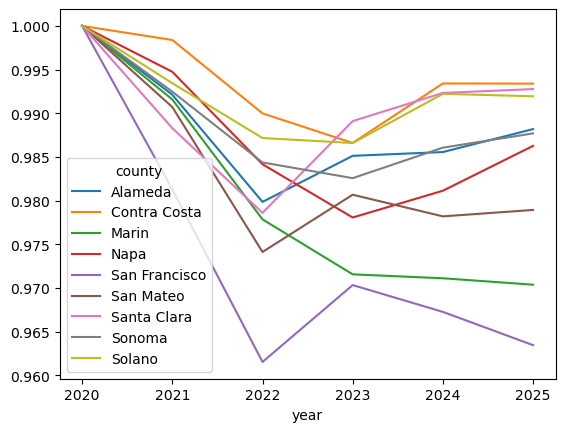

In [56]:
e5_long_bayarea.loc[:, :, 'POPULATION',
                    'Total'].unstack(1).sum(axis=1)  # .plot()

e5_county_pop = e5_long_bayarea.loc[:, :, 'POPULATION', 'Total'].unstack(1)
e5_county_pop.div(e5_county_pop.loc[2020]).plot()

# Household Trends

<Axes: xlabel='year'>

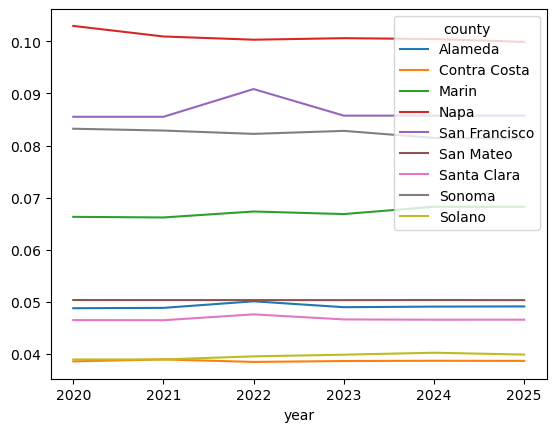

In [58]:
# vacancy holds stable
e5_county_vac = e5_long_bayarea.loc[:, :, 'HOUSING UNITS', 'Vacancy Rate'].unstack(1)
e5_county_vac.plot()

<Axes: xlabel='year'>

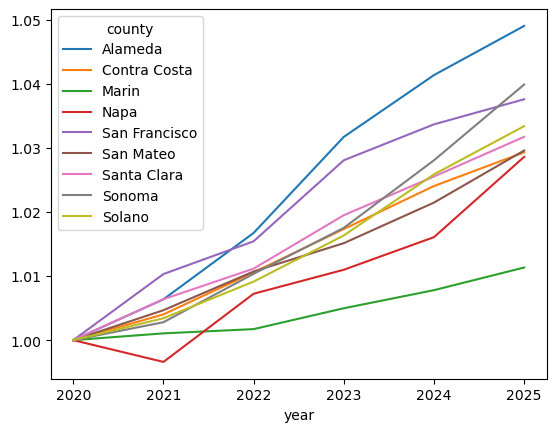

In [59]:
e5_county_hh = e5_long_bayarea.loc[:, :, 'HOUSING UNITS', 'Occupied'].unstack(1)
e5_county_hh.div(e5_county_hh.loc[2020]).plot()

<Axes: xlabel='year'>

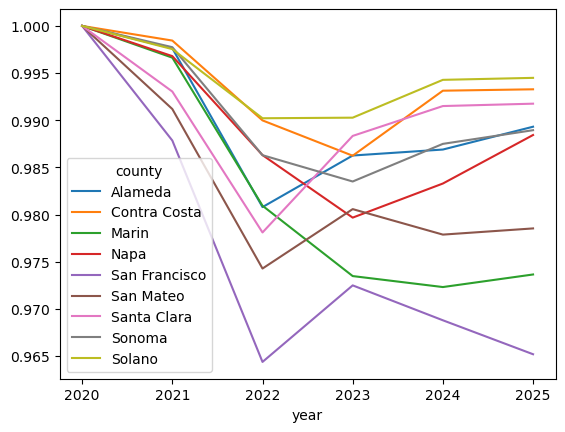

In [60]:
e5_county_pop = e5_long_bayarea.loc[:, :, 'POPULATION', 'Household'].unstack(1)
e5_county_pop.div(e5_county_pop.loc[2020]).plot()

# Viz: County Comparisons

In [61]:
for_facet = pd.concat([
    e5_county_pop.div(e5_county_pop.loc[2020]),
    e5_county_hh.div(e5_county_hh.loc[2020])],keys=['Household Population','Households'],names=['variable']).stack()
for_facet

variable              year  county       
Household Population  2020  Alameda          1.000000
                            Contra Costa     1.000000
                            Marin            1.000000
                            Napa             1.000000
                            San Francisco    1.000000
                                               ...   
Households            2025  San Francisco    1.037572
                            San Mateo        1.029575
                            Santa Clara      1.031712
                            Sonoma           1.039872
                            Solano           1.033375
Length: 108, dtype: float64

## Regional Aggregate

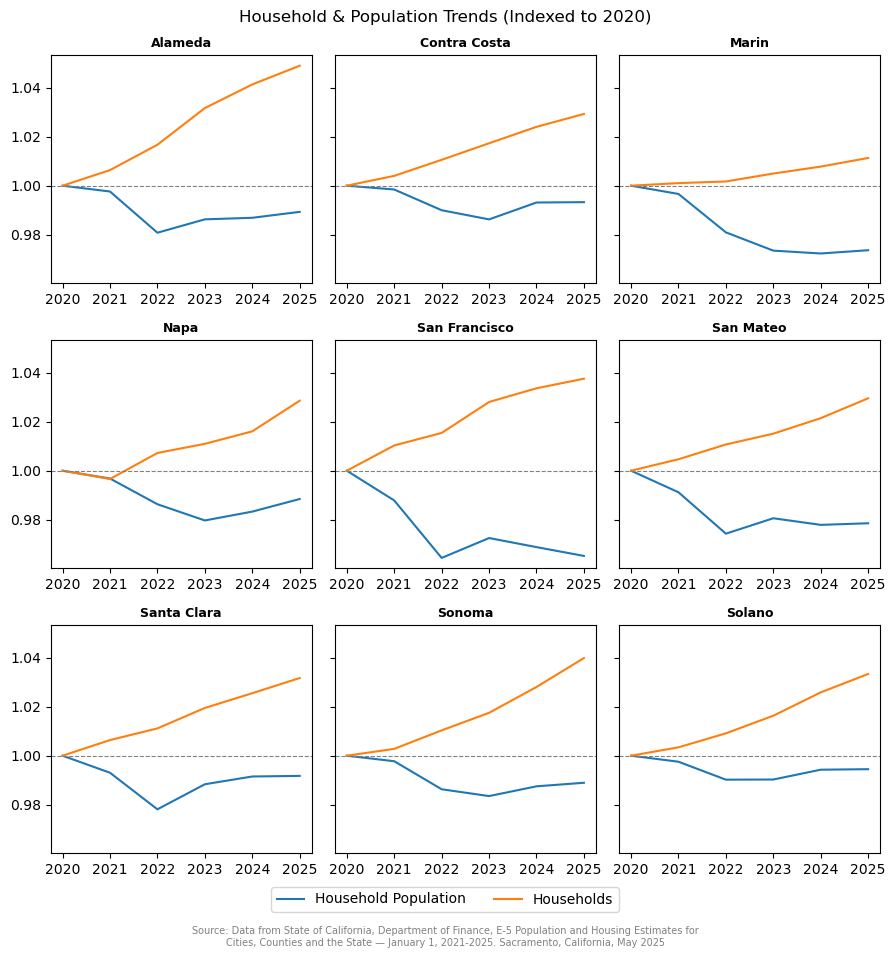

In [62]:
import matplotlib.pyplot as plt

counties = list(e5_county_hh.columns)
fig, axes = plt.subplots(3, 3, figsize=(9, 9), sharey=True)

for ax, county in zip(axes.flatten(), counties):
    for var, group in for_facet.xs(county, level='county').unstack('variable').items():
        ax.plot(group.index, group.values, label=var)
    ax.set_title(county, fontsize=9, fontweight='bold')
    ax.axhline(1, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.03))
fig.suptitle('Household & Population Trends (Indexed to 2020)', fontsize=12)
plt.tight_layout()
fig.text(0.5, -0.06, 
         'Source: Data from State of California, Department of Finance, E-5 Population and Housing Estimates for\n'
         'Cities, Counties and the State — January 1, 2021-2025. Sacramento, California, May 2025',
         ha='center', fontsize=7, color='gray')
plt.show()

## 3x3 Facet Plot by County

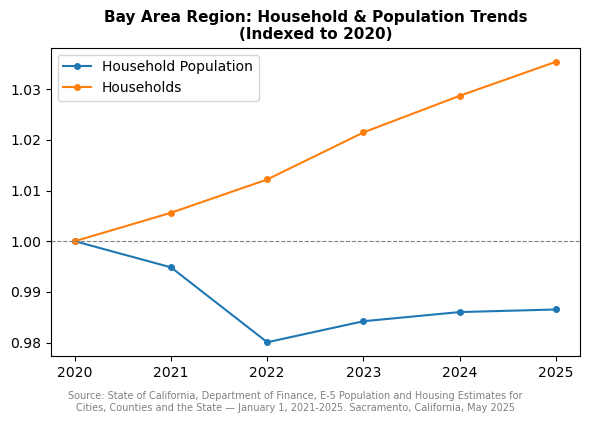

In [63]:
# Regional aggregate trend (indexed to 2020 (census day))
region_pop = e5_county_pop.sum(axis=1)
region_hh = e5_county_hh.sum(axis=1)

region_for_plot = pd.DataFrame({
    'Household Population': region_pop / region_pop.loc[2020],
    'Households': region_hh / region_hh.loc[2020]
})

fig, ax = plt.subplots(figsize=(6, 4))
for col in region_for_plot.columns:
    ax.plot(region_for_plot.index, region_for_plot[col], label=col, marker='o', markersize=4)

ax.axhline(1, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Bay Area Region: Household & Population Trends\n(Indexed to 2020)', fontsize=11, fontweight='bold')
ax.legend()
ax.set_xlabel('')
plt.tight_layout()
fig.text(0.5, -0.04,
         'Source: State of California, Department of Finance, E-5 Population and Housing Estimates for\n'
         'Cities, Counties and the State — January 1, 2021-2025. Sacramento, California, May 2025',
         ha='center', fontsize=7, color='gray')
plt.show()